# 🔬 OncoScan — Module 1: Symptom Intelligence Engine
## Run each cell one by one. Press the ▶ button on the left of each cell.
---
**No coding experience needed. Just press play on each cell in order.**

---
# CELL 1 — Install everything needed
### ▶ Press play. Wait until you see ✅ Done

In [1]:
# CELL 1 — Install packages
# This downloads all the tools we need. Takes about 1 minute.

!pip install -q xgboost shap scikit-learn pandas numpy matplotlib seaborn imbalanced-learn

print('✅ Done — all tools installed')

✅ Done — all tools installed


---
# CELL 2 — Load all the tools into memory
### ▶ Press play. Wait until you see ✅ Ready

In [2]:
# CELL 2 — Import everything
# Think of this like opening all the apps before you start working

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    average_precision_score, brier_score_loss
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Colors for our charts
NAVY = '#0A2B5C'
TEAL = '#0D7377'
RED  = '#C0392B'
PURP = '#8E44AD'

# Make charts look clean
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8FAFC',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False
})

np.random.seed(42)
print('✅ Ready — all tools loaded')

✅ Ready — all tools loaded


---
# CELL 3 — Create patient data
### ▶ Press play. This creates 3000 fake patients to train on.
### Later you replace this with real data from Kaggle or MIMIC.

In [3]:
# CELL 3 — Create simulated patient data
#
# We are making 3000 fake patients with realistic symptoms.
# Each patient has age, sex, symptoms, and a label (cancer yes/no).
# The symptoms are weighted based on real clinical evidence.
#
# ─────────────────────────────────────────────────────────────────
# WHEN YOU HAVE REAL DATA:
# Skip this cell and go to CELL 3B below to load your own CSV file
# ─────────────────────────────────────────────────────────────────

# These are the 11 alarm symptoms we track
SYMPTOM_COLS = [
    'rectal_bleeding',    # blood in stool
    'weight_loss',        # unexplained weight loss
    'dysphagia',          # difficulty swallowing
    'abdominal_pain',     # persistent stomach pain
    'change_bowel_habit', # change in toilet habits
    'early_satiety',      # feeling full too quickly
    'jaundice',           # yellow skin or eyes
    'fatigue',            # unexplained tiredness
    'palpable_mass',      # lump felt in stomach
    'iron_deficiency',    # low iron in blood test
    'nausea_vomiting'     # nausea or vomiting
]

n = 3000  # number of patients

df = pd.DataFrame()

# Basic patient info
df['age']  = np.random.normal(58, 14, n).clip(18, 90).astype(int)
df['sex']  = np.random.binomial(1, 0.5, n)   # 1=Male, 0=Female
df['bmi']  = np.random.normal(26.5, 5, n).clip(15, 50)

# Symptom presence (1=yes, 0=no) — based on real population rates
symptom_rates = {
    'rectal_bleeding': 0.12,    'weight_loss': 0.18,
    'dysphagia': 0.08,          'abdominal_pain': 0.45,
    'change_bowel_habit': 0.30, 'early_satiety': 0.20,
    'jaundice': 0.04,           'fatigue': 0.50,
    'palpable_mass': 0.05,      'iron_deficiency': 0.15,
    'nausea_vomiting': 0.35
}
for symptom, rate in symptom_rates.items():
    df[symptom] = np.random.binomial(1, rate, n)

# Other clinical info
df['symptom_duration_wks'] = np.random.exponential(8, n).clip(1, 52).astype(int)
df['family_history']        = np.random.binomial(1, 0.12, n)  # family cancer history
df['prior_gi_diagnosis']    = np.random.binomial(1, 0.25, n)  # IBS, GERD etc

# Count how many alarm symptoms each patient has
df['alarm_count'] = df[SYMPTOM_COLS].sum(axis=1)

# ── Generate cancer label ──────────────────────────────────────────────────
# Based on clinical evidence — which symptoms most predict cancer
log_odds = (
    -4.5
    + 0.04 * df['age']               # older = higher risk
    + 0.3  * df['sex']               # male slightly higher
    + 0.8  * df['rectal_bleeding']   # strong alarm
    + 0.9  * df['weight_loss']       # strong alarm
    + 0.7  * df['dysphagia']         # strong alarm
    + 0.5  * df['abdominal_pain']
    + 0.6  * df['change_bowel_habit']
    + 0.5  * df['early_satiety']
    + 1.4  * df['jaundice']          # very strong alarm
    + 0.3  * df['fatigue']
    + 1.6  * df['palpable_mass']     # strongest alarm
    + 0.7  * df['iron_deficiency']
    + 0.4  * df['nausea_vomiting']
    + 0.03 * df['symptom_duration_wks']
    + 0.6  * df['family_history']
    - 0.3  * df['prior_gi_diagnosis'] # prior benign lowers suspicion
    + 0.1  * df['alarm_count']
    + np.random.normal(0, 0.5, n)    # natural variation
)
probability = 1 / (1 + np.exp(-log_odds))
df['cancer_confirmed'] = np.random.binomial(1, probability)

# ── Summary ────────────────────────────────────────────────────────────────
total    = len(df)
positive = df['cancer_confirmed'].sum()
negative = total - positive

print(f'✅ Dataset created successfully')
print(f'')
print(f'   Total patients    : {total}')
print(f'   Cancer confirmed  : {positive} ({positive/total:.1%})')
print(f'   No cancer         : {negative} ({negative/total:.1%})')
print(f'   Features per patient: {len(df.columns)}')
print(f'')
print('First 5 rows of your dataset:')
df.head()

✅ Dataset created successfully

   Total patients    : 3000
   Cancer confirmed  : 1354 (45.1%)
   No cancer         : 1646 (54.9%)
   Features per patient: 19

First 5 rows of your dataset:


,age,sex,bmi,rectal_bleeding,weight_loss,dysphagia,abdominal_pain,change_bowel_habit,early_satiety,jaundice,fatigue,palpable_mass,iron_deficiency,nausea_vomiting,symptom_duration_wks,family_history,prior_gi_diagnosis,alarm_count,cancer_confirmed
0,64,1,25.548796,0,0,0,1,1,1,0,0,0,0,0,4,0,0,3,1
1,56,1,19.012767,0,0,1,0,1,0,0,0,0,0,0,1,0,0,2,0
2,67,0,33.316145,0,0,0,1,0,0,0,0,0,0,0,6,0,1,1,0
3,79,1,24.981870,0,0,0,1,0,0,0,0,0,1,0,1,0,0,2,0
4,54,0,24.055569,0,0,0,0,0,0,0,1,0,0,0,2,0,0,1,0


---
# CELL 3B — Load YOUR OWN data from Kaggle (optional)
### Only run this if you downloaded a CSV from Kaggle
### Skip this cell if you are using simulated data above

In [4]:
# CELL 3B — Load real CSV data
# Only run this cell if you have a real CSV file from Kaggle
#
# HOW TO USE:
# 1. Click the folder icon 📁 on the left side of Colab
# 2. Click the upload button (page with arrow icon)
# 3. Upload your CSV file
# 4. Replace 'your_file.csv' below with your actual filename
# 5. Run this cell

# ── UNCOMMENT THESE LINES WHEN YOU HAVE A REAL FILE ───────────────────────

# df_real = pd.read_csv('your_file.csv')   # <-- change filename here
#
# print('Your file columns are:')
# print(df_real.columns.tolist())
# print(f'\nRows: {len(df_real)}')
# df_real.head()

# ── AFTER SEEING YOUR COLUMNS ─────────────────────────────────────────────
# Send me (Claude) the column names and I will write the exact
# mapping code for your specific dataset. Every dataset is different.

print('This cell is ready — upload your CSV and follow the instructions above')

This cell is ready — upload your CSV and follow the instructions above


---
# CELL 4 — Explore the data with charts
### ▶ Press play. You will see 4 charts explaining your data.

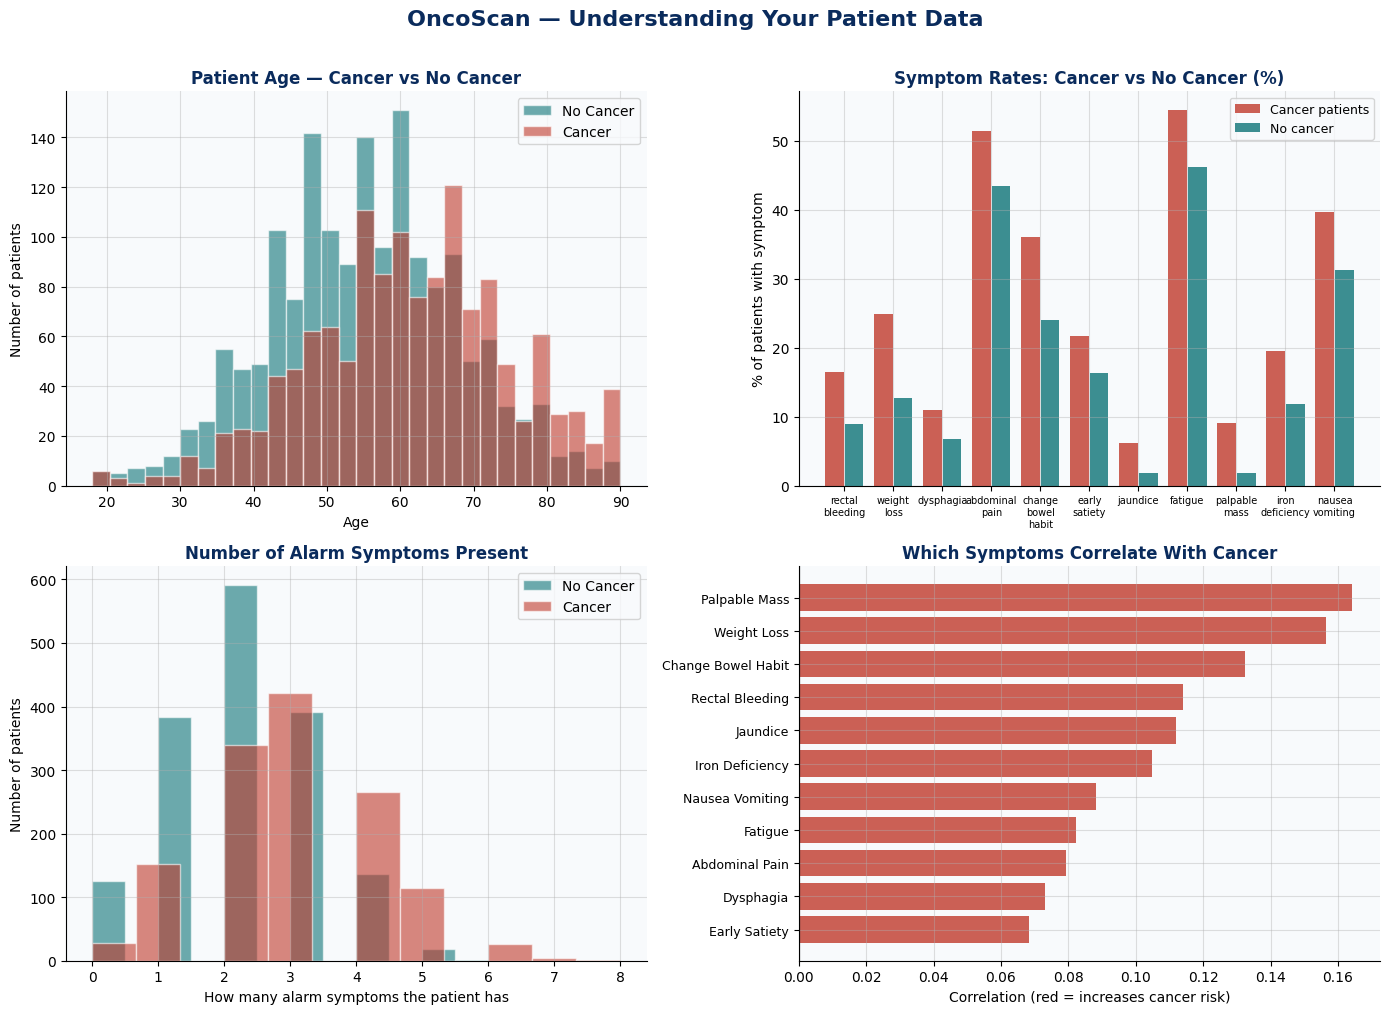

✅ Charts saved as data_exploration.png

What you are seeing:
  Chart 1 — Cancer patients are generally older
  Chart 2 — Red bars much higher = that symptom strongly suggests cancer
  Chart 3 — Cancer patients have more alarm symptoms
  Chart 4 — Palpable mass and jaundice are the strongest individual predictors


In [5]:
# CELL 4 — Explore the data
# This shows you what the data looks like before training

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('OncoScan — Understanding Your Patient Data',
             fontsize=16, fontweight='bold', color=NAVY, y=1.01)

# ── Chart 1: Age distribution ─────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(df[df['cancer_confirmed']==0]['age'],
        bins=30, alpha=0.6, color=TEAL, label='No Cancer', edgecolor='white')
ax.hist(df[df['cancer_confirmed']==1]['age'],
        bins=30, alpha=0.6, color=RED,  label='Cancer',    edgecolor='white')
ax.set_title('Patient Age — Cancer vs No Cancer', fontweight='bold', color=NAVY)
ax.set_xlabel('Age'); ax.set_ylabel('Number of patients')
ax.legend()
# What this tells you: cancer patients tend to be older

# ── Chart 2: Which symptoms appear most in cancer patients ────────────────
ax = axes[0, 1]
cancer_rates    = df[df['cancer_confirmed']==1][SYMPTOM_COLS].mean() * 100
noncancer_rates = df[df['cancer_confirmed']==0][SYMPTOM_COLS].mean() * 100
x = np.arange(len(SYMPTOM_COLS))
ax.bar(x - 0.2, cancer_rates,    0.38, label='Cancer patients', color=RED,  alpha=0.8)
ax.bar(x + 0.2, noncancer_rates, 0.38, label='No cancer',       color=TEAL, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([s.replace('_', '\n') for s in SYMPTOM_COLS], fontsize=7)
ax.set_title('Symptom Rates: Cancer vs No Cancer (%)', fontweight='bold', color=NAVY)
ax.set_ylabel('% of patients with symptom')
ax.legend(fontsize=9)
# What this tells you: which symptoms matter most

# ── Chart 3: How many alarm symptoms do patients have ─────────────────────
ax = axes[1, 0]
ax.hist(df[df['cancer_confirmed']==0]['alarm_count'],
        bins=12, alpha=0.6, color=TEAL, label='No Cancer', edgecolor='white')
ax.hist(df[df['cancer_confirmed']==1]['alarm_count'],
        bins=12, alpha=0.6, color=RED,  label='Cancer',    edgecolor='white')
ax.set_title('Number of Alarm Symptoms Present', fontweight='bold', color=NAVY)
ax.set_xlabel('How many alarm symptoms the patient has')
ax.set_ylabel('Number of patients')
ax.legend()
# What this tells you: more alarm symptoms = higher cancer risk

# ── Chart 4: Correlation between symptoms and cancer ─────────────────────
ax = axes[1, 1]
correlations = df[SYMPTOM_COLS].corrwith(df['cancer_confirmed']).sort_values(ascending=True)
colors_bar   = [RED if x > 0 else TEAL for x in correlations]
ax.barh(correlations.index, correlations.values, color=colors_bar, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Which Symptoms Correlate With Cancer', fontweight='bold', color=NAVY)
ax.set_xlabel('Correlation (red = increases cancer risk)')
ax.set_yticklabels([s.replace('_', ' ').title() for s in correlations.index], fontsize=9)
# What this tells you: palpable mass and jaundice are strongest signals

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Charts saved as data_exploration.png')
print('')
print('What you are seeing:')
print('  Chart 1 — Cancer patients are generally older')
print('  Chart 2 — Red bars much higher = that symptom strongly suggests cancer')
print('  Chart 3 — Cancer patients have more alarm symptoms')
print('  Chart 4 — Palpable mass and jaundice are the strongest individual predictors')

---
# CELL 5 — Prepare data for training
### ▶ Press play. This adds extra useful features and splits data into train/test.

In [6]:
# CELL 5 — Feature engineering and data splitting
#
# Feature engineering means creating NEW columns from existing ones.
# For example: "does the patient have 3+ alarm symptoms" is more useful
# than just counting them separately.

def add_extra_features(df):
    d = df.copy()

    # How many alarm symptoms total
    d['alarm_count']         = d[SYMPTOM_COLS].sum(axis=1)

    # Is the count high (3 or more is clinically significant)
    d['many_alarms']         = (d['alarm_count'] >= 3).astype(int)

    # Age groups (cancer risk jumps at 50 and 60)
    d['age_over_50']         = (d['age'] >= 50).astype(int)
    d['age_over_60']         = (d['age'] >= 60).astype(int)

    # Age combined with alarm count (older + more symptoms = very high risk)
    d['age_x_alarms']        = d['age'] * d['alarm_count']

    # Dangerous combinations from clinical literature
    d['bleeding_and_anaemia']    = d['rectal_bleeding']     * d['iron_deficiency']
    d['weight_loss_and_jaundice']= d['weight_loss']         * d['jaundice']
    d['mass_and_weight_loss']    = d['palpable_mass']       * d['weight_loss']
    d['bowel_and_bleeding']      = d['change_bowel_habit']  * d['rectal_bleeding']

    # Symptoms lasting 6+ weeks are more worrying
    d['symptoms_chronic']    = (d['symptom_duration_wks'] >= 6).astype(int)
    d['log_duration']        = np.log1p(d['symptom_duration_wks'])

    # Family history + age combination
    d['age_x_family_hx']     = d['age'] * d['family_history']

    return d

# Apply feature engineering
df_ready = add_extra_features(df)

# All feature columns (original + engineered)
ALL_FEATURES = [
    # Original
    'age', 'sex', 'bmi',
    'rectal_bleeding', 'weight_loss', 'dysphagia', 'abdominal_pain',
    'change_bowel_habit', 'early_satiety', 'jaundice', 'fatigue',
    'palpable_mass', 'iron_deficiency', 'nausea_vomiting',
    'symptom_duration_wks', 'family_history', 'prior_gi_diagnosis',
    # Engineered
    'alarm_count', 'many_alarms',
    'age_over_50', 'age_over_60', 'age_x_alarms', 'age_x_family_hx',
    'bleeding_and_anaemia', 'weight_loss_and_jaundice',
    'mass_and_weight_loss', 'bowel_and_bleeding',
    'symptoms_chronic', 'log_duration'
]

X = df_ready[ALL_FEATURES]   # features (inputs)
y = df_ready['cancer_confirmed']  # label (what we're predicting)

# Split: 80% for training, 20% for testing
# stratify=y means both splits have same cancer/non-cancer ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# SMOTE — creates extra examples of the minority class (cancer patients)
# so the model doesn't just learn to say 'no cancer' for everything
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('✅ Data prepared for training')
print(f'')
print(f'   Training patients : {len(X_train_bal)} (after balancing)')
print(f'   Testing patients  : {len(X_test)}')
print(f'   Features used     : {len(ALL_FEATURES)}')
print(f'   Cancer in test    : {y_test.sum()} ({y_test.mean():.1%})')

✅ Data prepared for training

   Training patients : 2634 (after balancing)
   Testing patients  : 600
   Features used     : 29
   Cancer in test    : 271 (45.2%)


---
# CELL 6 — Train the AI models
### ▶ Press play. This trains 4 models. Takes about 1-2 minutes.
### You will see ✅ next to each model as it finishes.

In [7]:
# CELL 6 — Train 4 models
#
# We train 4 different models and combine them.
# Like getting 4 different doctors to look at the same patient
# and taking a vote — more reliable than just one opinion.

print('Training models... please wait')
print('')

# ── Model 1: Logistic Regression ──────────────────────────────────────────
# Simple, transparent, doctors understand it
# Good for publications because you can show the exact coefficients
model_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(C=0.1, max_iter=1000, random_state=42))
])
model_lr.fit(X_train_bal, y_train_bal)
print('  ✅ Model 1 done — Logistic Regression (transparent, interpretable)')

# ── Model 2: XGBoost ──────────────────────────────────────────────────────
# More powerful, handles complex patterns in data
# Usually gives the best performance on medical tabular data
model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
model_xgb.fit(X_train_bal, y_train_bal)
print('  ✅ Model 2 done — XGBoost (high performance)')

# ── Model 3: Random Forest ────────────────────────────────────────────────
# Builds many decision trees and averages them
# Very stable — doesn't overfit easily
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train_bal, y_train_bal)
print('  ✅ Model 3 done — Random Forest (stable)')

# ── Model 4: Ensemble (combination of all three) ──────────────────────────
# All 3 models vote together — XGBoost gets double vote as it's strongest
# This is your FINAL model — most accurate and reliable
model_ensemble = VotingClassifier(
    estimators=[
        ('lr',  model_lr),
        ('xgb', model_xgb),
        ('rf',  model_rf)
    ],
    voting='soft',
    weights=[1, 2, 1]  # XGBoost counts double
)
model_ensemble.fit(X_train_bal, y_train_bal)
print('  ✅ Model 4 done — Ensemble (LR + XGBoost + RF combined)')

print('')
print('✅ All models trained successfully')
print('   Next: we test them on patients the model has never seen')

Training models... please wait

  ✅ Model 1 done — Logistic Regression (transparent, interpretable)
  ✅ Model 2 done — XGBoost (high performance)
  ✅ Model 3 done — Random Forest (stable)
  ✅ Model 4 done — Ensemble (LR + XGBoost + RF combined)

✅ All models trained successfully
   Next: we test them on patients the model has never seen


---
# CELL 7 — Test the models and see results
### ▶ Press play. This is the most important step.
### You will see your AUROC score — write it down.

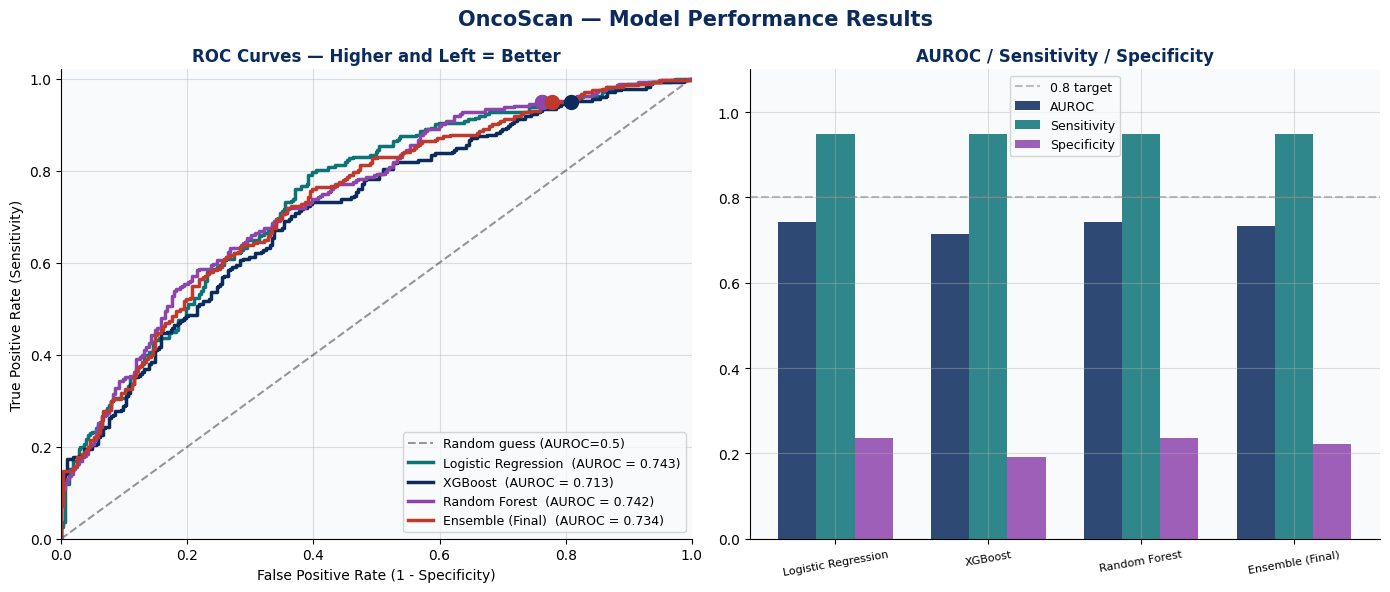

✅ Results saved as model_results.png

══ YOUR RESULTS ═════════════════════════════════════════
                     AUROC  Sensitivity  Specificity    PPV    NPV
Logistic Regression  0.743        0.948        0.237  0.506  0.848
XGBoost              0.713        0.948        0.191  0.491  0.818
Random Forest        0.742        0.948        0.237  0.506  0.848
Ensemble (Final)     0.734        0.948        0.222  0.501  0.839

🎯 Your final model AUROC: 0.734
   📈 Decent start — will improve with real patient data

📝 Write down your Ensemble AUROC — this is your headline number


In [8]:
# CELL 7 — Evaluate model performance
#
# AUROC explained simply:
#   1.0 = perfect (model always correct)
#   0.9 = excellent
#   0.8 = good (publishable)
#   0.7 = fair
#   0.5 = same as random guessing
#
# Sensitivity = how many cancer patients did we correctly identify?
# Specificity = how many healthy patients did we correctly clear?

all_models = {
    'Logistic Regression': model_lr,
    'XGBoost':             model_xgb,
    'Random Forest':       model_rf,
    'Ensemble (Final)':    model_ensemble
}
colors_list = [TEAL, NAVY, PURP, RED]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('OncoScan — Model Performance Results',
             fontsize=15, fontweight='bold', color=NAVY)

results = {}

# ── ROC Curve (left chart) ────────────────────────────────────────────────
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess (AUROC=0.5)')

for (name, model), color in zip(all_models.items(), colors_list):

    # Get probability predictions
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate AUROC
    auroc = roc_auc_score(y_test, y_prob)

    # Get the ROC curve points
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Find sensitivity/specificity at best threshold
    # We target 95% sensitivity (we don't want to miss cancer patients)
    idx_95 = np.argmin(np.abs(tpr - 0.95))
    sens   = tpr[idx_95]
    spec   = 1 - fpr[idx_95]

    # Calculate PPV and NPV
    thresh  = thresholds[idx_95]
    y_pred  = (y_prob >= thresh).astype(int)
    cm      = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # precision
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # negative predictive value

    results[name] = {
        'AUROC':       round(auroc, 3),
        'Sensitivity': round(float(sens), 3),
        'Specificity': round(float(spec), 3),
        'PPV':         round(ppv, 3),
        'NPV':         round(npv, 3)
    }

    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{name}  (AUROC = {auroc:.3f})')
    ax.scatter(fpr[idx_95], tpr[idx_95], color=color, s=100, zorder=5)

ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves — Higher and Left = Better', fontweight='bold', color=NAVY)
ax.legend(fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

# ── Bar chart (right chart) ────────────────────────────────────────────────
ax2 = axes[1]
metrics_df = pd.DataFrame(results).T
x = np.arange(len(all_models))
w = 0.25
ax2.bar(x - w,  metrics_df['AUROC'],       w, label='AUROC',       color=NAVY, alpha=0.85)
ax2.bar(x,      metrics_df['Sensitivity'], w, label='Sensitivity', color=TEAL, alpha=0.85)
ax2.bar(x + w,  metrics_df['Specificity'], w, label='Specificity', color=PURP, alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(list(all_models.keys()), fontsize=8, rotation=10)
ax2.set_ylim([0, 1.1])
ax2.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 target')
ax2.set_title('AUROC / Sensitivity / Specificity', fontweight='bold', color=NAVY)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print results table ───────────────────────────────────────────────────
print('✅ Results saved as model_results.png')
print('')
print('══ YOUR RESULTS ═════════════════════════════════════════')
print(pd.DataFrame(results).T.to_string())
print('')
ensemble_auroc = results['Ensemble (Final)']['AUROC']
print(f'🎯 Your final model AUROC: {ensemble_auroc}')
if ensemble_auroc >= 0.85:
    print('   ⭐ Excellent result — strong for publication')
elif ensemble_auroc >= 0.80:
    print('   ✅ Good result — publishable with real data validation')
else:
    print('   📈 Decent start — will improve with real patient data')
print('')
print('📝 Write down your Ensemble AUROC — this is your headline number')

---
# CELL 8 — Calibration curve
### ▶ Press play. This checks if the model's probabilities are trustworthy.
### Closer to the diagonal line = more trustworthy

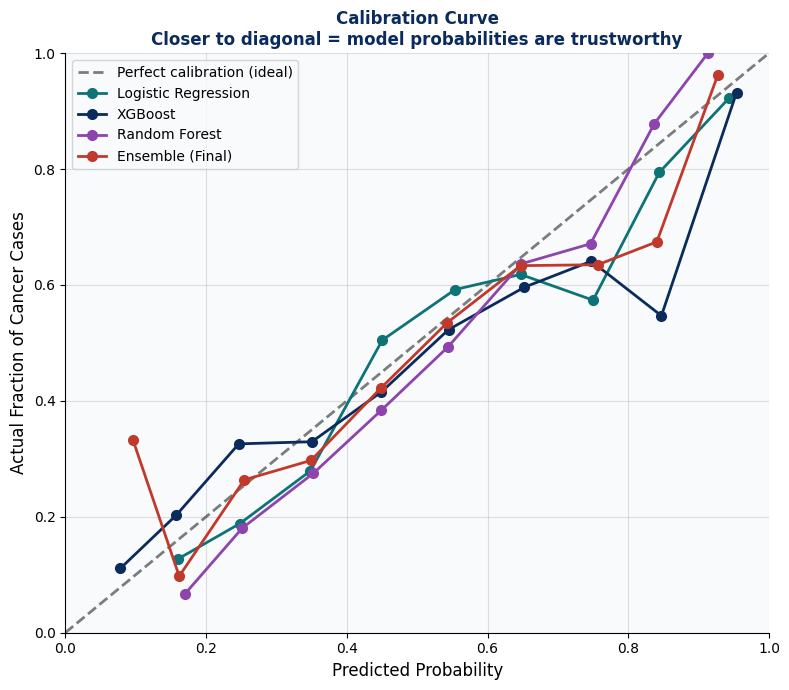

✅ Calibration curve saved as calibration.png

Reading this chart:
  Lines close to diagonal = good (model is honest about uncertainty)
  Lines above diagonal    = model overestimates risk
  Lines below diagonal    = model underestimates risk


In [9]:
# CELL 8 — Calibration curve
#
# Why this matters:
# If the model says "40% cancer risk" — does that mean 40% of those
# patients actually have cancer?
# A calibrated model means YES — the probabilities are real.
# This is essential for clinical use and for peer review.

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5,
        label='Perfect calibration (ideal)', linewidth=2)

for (name, model), color in zip(all_models.items(), colors_list):
    y_prob = model.predict_proba(X_test)[:, 1]
    fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
    ax.plot(mean_pred, fraction_pos, 'o-',
            color=color, lw=2, ms=7, label=name)

ax.set_xlabel('Predicted Probability', fontsize=12)
ax.set_ylabel('Actual Fraction of Cancer Cases', fontsize=12)
ax.set_title('Calibration Curve\nCloser to diagonal = model probabilities are trustworthy',
             fontweight='bold', color=NAVY, fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Calibration curve saved as calibration.png')
print('')
print('Reading this chart:')
print('  Lines close to diagonal = good (model is honest about uncertainty)')
print('  Lines above diagonal    = model overestimates risk')
print('  Lines below diagonal    = model underestimates risk')

---
# CELL 9 — SHAP: Which symptoms matter most?
### ▶ Press play. This shows WHY the model makes each decision.
### This is what makes your research explainable to doctors.

Calculating SHAP values... takes about 30 seconds


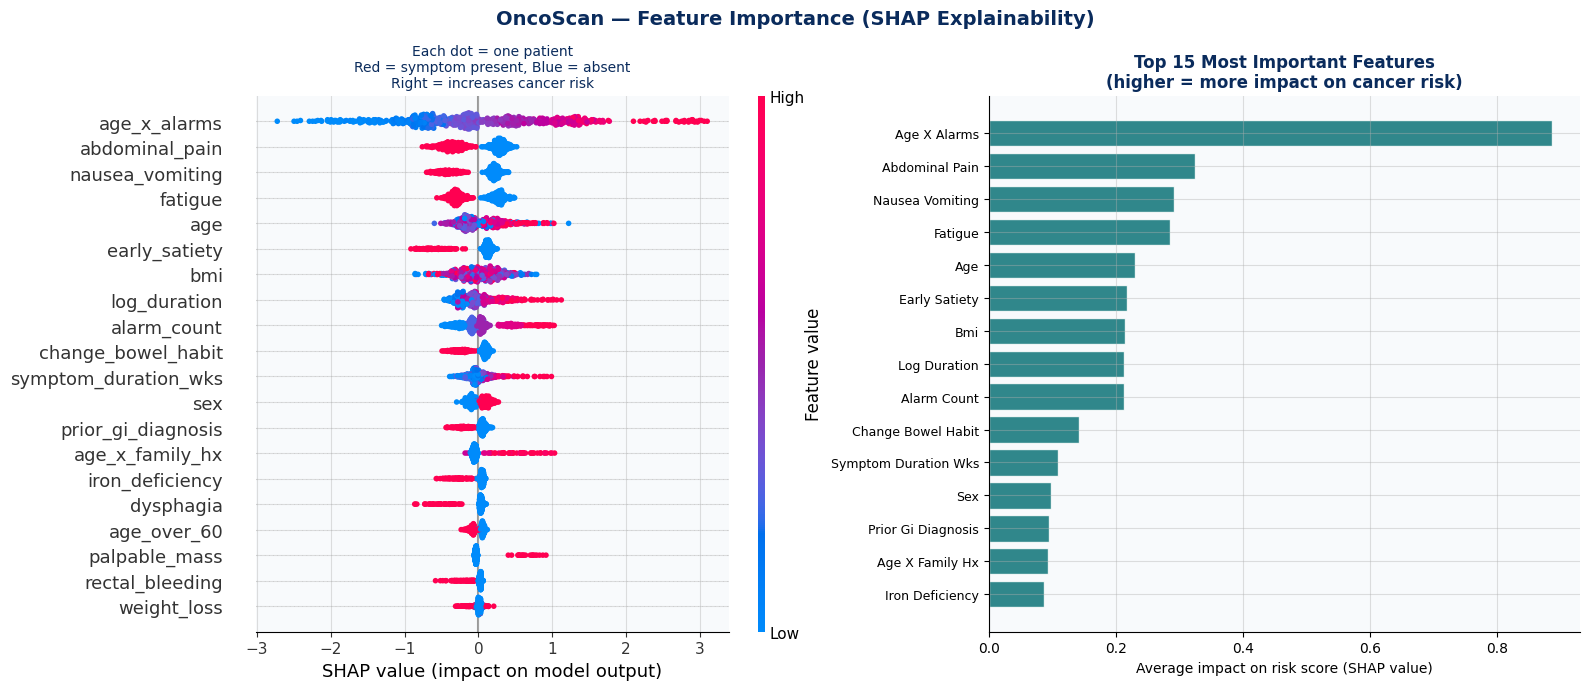

✅ SHAP analysis complete — saved as shap_importance.png

Top 5 most important symptoms for cancer prediction:
  1. Age X Alarms                         importance = 0.8867
  2. Abdominal Pain                       importance = 0.3241
  3. Nausea Vomiting                      importance = 0.2916
  4. Fatigue                              importance = 0.2852
  5. Age                                  importance = 0.2297


In [10]:
# CELL 9 — SHAP Explainability
#
# SHAP answers: for each patient, which symptoms pushed the
# risk score up or down — and by how much?
#
# This is critical for:
#   1. Doctor trust (they can see the reasoning)
#   2. Publication (reviewers require explainability)
#   3. Regulatory approval (FDA wants to know how it works)

print('Calculating SHAP values... takes about 30 seconds')

explainer   = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('OncoScan — Feature Importance (SHAP Explainability)',
             fontsize=14, fontweight='bold', color=NAVY)

# ── Left: Beeswarm plot ───────────────────────────────────────────────────
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, show=False, plot_size=None)
axes[0].set_title(
    'Each dot = one patient\nRed = symptom present, Blue = absent\nRight = increases cancer risk',
    fontsize=10, color=NAVY
)

# ── Right: Bar chart — average importance ─────────────────────────────────
mean_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=ALL_FEATURES
).sort_values(ascending=True).tail(15)

axes[1].barh(mean_importance.index, mean_importance.values,
             color=TEAL, alpha=0.85, edgecolor='white')
axes[1].set_title('Top 15 Most Important Features\n(higher = more impact on cancer risk)',
                  fontweight='bold', color=NAVY)
axes[1].set_xlabel('Average impact on risk score (SHAP value)')
axes[1].set_yticklabels(
    [f.replace('_', ' ').title() for f in mean_importance.index],
    fontsize=9
)

plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 5 most important features
top5 = mean_importance.tail(5)[::-1]
print('✅ SHAP analysis complete — saved as shap_importance.png')
print('')
print('Top 5 most important symptoms for cancer prediction:')
for i, (feat, val) in enumerate(top5.items(), 1):
    print(f'  {i}. {feat.replace("_", " ").title():35s}  importance = {val:.4f}')

---
# CELL 10 — Cross validation (the numbers for your paper)
### ▶ Press play. Takes 2-3 minutes.
### These are the exact numbers you put in your research paper.

Running 5-fold cross-validation...
(Tests each model 5 times on different data splits)

  Logistic Regression        AUROC = 0.756 ± 0.009
  XGBoost                    AUROC = 0.719 ± 0.010
  Random Forest              AUROC = 0.744 ± 0.016
  Ensemble (Final)           AUROC = 0.740 ± 0.011



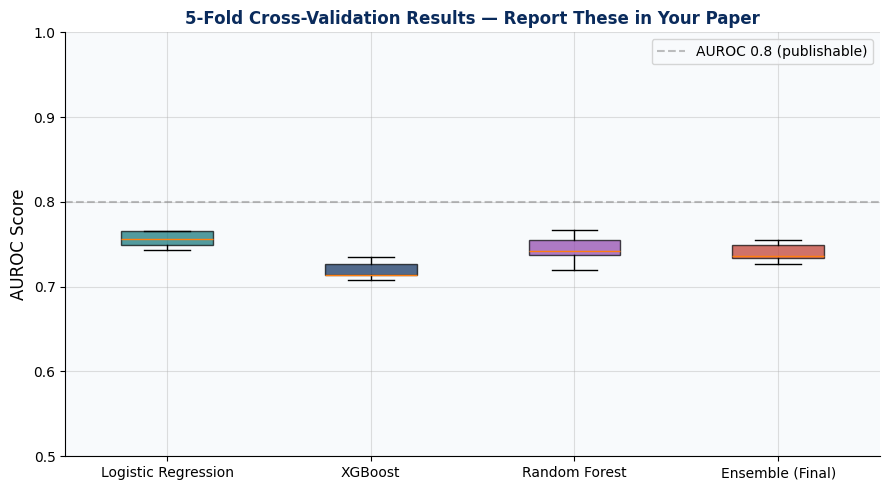

✅ Cross-validation complete — saved as cross_validation.png

══ COPY THIS INTO YOUR PAPER ════════════════════════════════
  Ensemble model 5-fold CV AUROC: 0.740 ± 0.011
  Individual fold scores: [np.float64(0.726), np.float64(0.736), np.float64(0.755), np.float64(0.749), np.float64(0.733)]
════════════════════════════════════════════════════════════=


In [11]:
# CELL 10 — 5-Fold Cross Validation
#
# Instead of testing on just one test set, we test 5 times
# on 5 different splits of the data.
# This gives a more honest, reliable performance estimate.
#
# In your paper you write:
# "The ensemble model achieved AUROC X.XX ± X.XX (5-fold CV)"

print('Running 5-fold cross-validation...')
print('(Tests each model 5 times on different data splits)')
print('')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in all_models.items():
    scores = cross_val_score(
        model, X, y,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    cv_results[name] = scores
    print(f'  {name:25s}  AUROC = {scores.mean():.3f} ± {scores.std():.3f}')

print('')

# Box plot of CV results
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    [cv_results[n] for n in all_models.keys()],
    patch_artist=True,
    labels=list(all_models.keys())
)
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='AUROC 0.8 (publishable)')
ax.set_ylabel('AUROC Score', fontsize=12)
ax.set_ylim([0.5, 1.0])
ax.set_title('5-Fold Cross-Validation Results — Report These in Your Paper',
             fontweight='bold', color=NAVY)
ax.legend()

plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

final_scores = cv_results['Ensemble (Final)']
print('✅ Cross-validation complete — saved as cross_validation.png')
print('')
print('══ COPY THIS INTO YOUR PAPER ════════════════════════════════')
print(f'  Ensemble model 5-fold CV AUROC: {final_scores.mean():.3f} ± {final_scores.std():.3f}')
print(f'  Individual fold scores: {[round(s,3) for s in final_scores]}')
print('════════════════════════════════════════════════════════════=')

---
# CELL 11 — Test with a real patient example
### ▶ Press play. Enter any patient's symptoms and see the risk output.
### This is exactly what a doctor would see.

In [12]:
# CELL 11 — Test with patient examples
#
# This is the actual clinical output — what a doctor sees.
# Change the numbers below to test different patients.
# 1 = symptom present, 0 = symptom absent

def assess_patient(patient, label='Patient'):
    """
    Takes patient symptoms as a dictionary.
    Returns risk tier with explanation.
    """
    df_p = pd.DataFrame([patient])
    df_p = add_extra_features(df_p)

    # Make sure all feature columns exist
    for col in ALL_FEATURES:
        if col not in df_p.columns:
            df_p[col] = 0

    prob = model_ensemble.predict_proba(df_p[ALL_FEATURES])[0, 1]

    # Risk tier thresholds (adjust based on your clinical judgment)
    if prob < 0.15:
        tier   = 'LOW'
        icon   = '🟢'
        action = 'Routine follow-up. Reassure patient and safety-net at 4 weeks.'
        color  = '\033[92m'  # green
    elif prob < 0.40:
        tier   = 'ELEVATED'
        icon   = '🟡'
        action = 'Non-urgent referral. Bloods + consider colonoscopy within 8 weeks.'
        color  = '\033[93m'  # yellow
    else:
        tier   = 'URGENT'
        icon   = '🔴'
        action = 'Urgent 2-week-wait referral. Do not delay — expedite workup.'
        color  = '\033[91m'  # red

    # Which symptoms drove this result (SHAP)
    shap_p = explainer.shap_values(df_p[ALL_FEATURES])[0]
    top3   = np.argsort(np.abs(shap_p))[-3:][::-1]

    print(f'─────────────────────────────────────────────')
    print(f' {label}')
    print(f'─────────────────────────────────────────────')
    print(f'  {icon}  RISK TIER    : {tier}')
    print(f'     Probability  : {prob:.1%}')
    print(f'     Action       : {action}')
    print(f'  Top reasons for this score:')
    for idx in top3:
        feat = ALL_FEATURES[idx]
        val  = shap_p[idx]
        direction = 'increases' if val > 0 else 'decreases'
        print(f'    • {feat.replace("_", " ").title():30s} {direction} risk')
    print()

    return prob


# ── TEST PATIENTS ─────────────────────────────────────────────────────────

print('═══════════════════════════════════════════════════════')
print('  OncoScan — Clinical Risk Assessment Output')
print('═══════════════════════════════════════════════════════')
print()

# Patient A — young woman, vague symptoms, low risk
assess_patient({
    'age': 32, 'sex': 0, 'bmi': 22.0,
    'rectal_bleeding': 0, 'weight_loss': 0,    'dysphagia': 0,
    'abdominal_pain': 1,  'change_bowel_habit': 0, 'early_satiety': 0,
    'jaundice': 0,        'fatigue': 1,         'palpable_mass': 0,
    'iron_deficiency': 0, 'nausea_vomiting': 1,
    'symptom_duration_wks': 2, 'family_history': 0, 'prior_gi_diagnosis': 1
}, 'Patient A — 32F, mild bloating and fatigue x2 weeks')

# Patient B — middle aged man, several alarm features
assess_patient({
    'age': 57, 'sex': 1, 'bmi': 29.0,
    'rectal_bleeding': 1, 'weight_loss': 1,     'dysphagia': 0,
    'abdominal_pain': 1,  'change_bowel_habit': 1, 'early_satiety': 0,
    'jaundice': 0,        'fatigue': 1,          'palpable_mass': 0,
    'iron_deficiency': 1, 'nausea_vomiting': 0,
    'symptom_duration_wks': 8, 'family_history': 1, 'prior_gi_diagnosis': 0
}, 'Patient B — 57M, rectal bleeding, weight loss, family history x8 weeks')

# Patient C — elderly man, multiple high-risk features
assess_patient({
    'age': 68, 'sex': 1, 'bmi': 20.5,
    'rectal_bleeding': 1, 'weight_loss': 1,     'dysphagia': 1,
    'abdominal_pain': 1,  'change_bowel_habit': 1, 'early_satiety': 1,
    'jaundice': 1,        'fatigue': 1,          'palpable_mass': 1,
    'iron_deficiency': 1, 'nausea_vomiting': 1,
    'symptom_duration_wks': 16, 'family_history': 1, 'prior_gi_diagnosis': 0
}, 'Patient C — 68M, jaundice, palpable mass, multiple alarms x16 weeks')

print('─────────────────────────────────────────────')
print('⚠️  Research prototype only. Not for clinical use.')
print('   Always apply clinical judgement.')

═══════════════════════════════════════════════════════
  OncoScan — Clinical Risk Assessment Output
═══════════════════════════════════════════════════════

─────────────────────────────────────────────
 Patient A — 32F, mild bloating and fatigue x2 weeks
─────────────────────────────────────────────
  🟡  RISK TIER    : ELEVATED
     Probability  : 18.7%
     Action       : Non-urgent referral. Bloods + consider colonoscopy within 8 weeks.
  Top reasons for this score:
    • Age X Alarms                   decreases risk
    • Nausea Vomiting                decreases risk
    • Fatigue                        decreases risk

─────────────────────────────────────────────
 Patient B — 57M, rectal bleeding, weight loss, family history x8 weeks
─────────────────────────────────────────────
  🔴  RISK TIER    : URGENT
     Probability  : 96.2%
     Action       : Urgent 2-week-wait referral. Do not delay — expedite workup.
  Top reasons for this score:
    • Age X Alarms                   inc

---
# CELL 12 — Save everything
### ▶ Press play. This saves your model and downloads results to your laptop.

In [15]:
# CELL 12 — Save model and download results

import pickle
import json
import os
import shutil

os.makedirs('oncoscan_output', exist_ok=True)

# Save the trained model
with open('oncoscan_output/model.pkl', 'wb') as f:
    pickle.dump(model_ensemble, f)

# Save feature list
with open('oncoscan_output/features.json', 'w') as f:
    json.dump(ALL_FEATURES, f, indent=2)

# Save results table as CSV
results_df = pd.DataFrame(results).T
results_df.to_csv('oncoscan_output/results.csv')

# Copy all charts
for chart in ['data_exploration.png', 'model_results.png',
              'calibration.png', 'shap_importance.png', 'cross_validation.png']:
    if os.path.exists(chart):
        shutil.copy(chart, f'oncoscan_output/{chart}')

# Zip everything and download
shutil.make_archive('oncoscan_output', 'zip', 'oncoscan_output')

print('✅ All files saved to oncoscan_output/')
print('')
print('   model.pkl          — your trained AI model')
print('   features.json      — list of features used')
print('   results.csv        — metrics table for your paper')
print('   data_exploration.png')
print('   model_results.png')
print('   calibration.png')
print('   shap_importance.png')
print('   cross_validation.png')
print('')
print('Downloading zip file to your laptop...')

try:
    from google.colab import files
    files.download('oncoscan_output.zip')
    print('✅ Download started — check your Downloads folder')
except:
    print('(Save manually from the folder icon on the left)')

✅ All files saved to oncoscan_output/

   model.pkl          — your trained AI model
   features.json      — list of features used
   results.csv        — metrics table for your paper
   data_exploration.png
   model_results.png
   calibration.png
   shap_importance.png
   cross_validation.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started — check your Downloads folder


---
# CELL 13 — Generate your Streamlit demo app
### ▶ Press play. This creates app.py — your live demo website.

In [14]:
# CELL 13 — Generate Streamlit app
#
# This creates a file called app.py
# Upload it to GitHub + deploy on share.streamlit.io
# You get a live URL anyone can use to test OncoScan

app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle

st.set_page_config(
    page_title="OncoScan — Cancer Risk Assessment",
    page_icon="🔬",
    layout="wide"
)

@st.cache_resource
def load_model():
    with open("oncoscan_output/model.pkl", "rb") as f:
        return pickle.load(f)

model = load_model()

SYMPTOM_COLS = [
    \'rectal_bleeding\', \'weight_loss\', \'dysphagia\', \'abdominal_pain\',
    \'change_bowel_habit\', \'early_satiety\', \'jaundice\', \'fatigue\',
    \'palpable_mass\', \'iron_deficiency\', \'nausea_vomiting\'
]

ALL_FEATURES = [
    \'age\', \'sex\', \'bmi\',
    \'rectal_bleeding\', \'weight_loss\', \'dysphagia\', \'abdominal_pain\',
    \'change_bowel_habit\', \'early_satiety\', \'jaundice\', \'fatigue\',
    \'palpable_mass\', \'iron_deficiency\', \'nausea_vomiting\',
    \'symptom_duration_wks\', \'family_history\', \'prior_gi_diagnosis\',
    \'alarm_count\', \'many_alarms\', \'age_over_50\', \'age_over_60\',
    \'age_x_alarms\', \'age_x_family_hx\',
    \'bleeding_and_anaemia\', \'weight_loss_and_jaundice\',
    \'mass_and_weight_loss\', \'bowel_and_bleeding\',
    \'symptoms_chronic\', \'log_duration\'
]

st.markdown("""
<div style="background:#0A2B5C;padding:20px 28px;border-radius:8px;margin-bottom:20px">
<h1 style="color:white;margin:0">🔬 OncoScan</h1>
<p style="color:#7EC8C8;margin:4px 0 0 0">Abdominal Cancer Symptom Risk Engine · Research Prototype</p>
</div>
""", unsafe_allow_html=True)

col1, col2 = st.columns([1, 1])

with col1:
    st.subheader("Patient Details")
    age      = st.slider("Age", 18, 90, 55)
    sex      = 1 if st.radio("Sex", ["Male", "Female"]) == "Male" else 0
    bmi      = st.number_input("BMI", 15.0, 50.0, 26.5)
    duration = st.slider("Symptom duration (weeks)", 1, 52, 4)
    fam_hx   = int(st.checkbox("Family history of GI cancer"))
    prior    = int(st.checkbox("Prior benign GI diagnosis (IBS, GERD)"))

    st.subheader("Symptoms Present")
    c1, c2 = st.columns(2)
    with c1:
        s1  = int(st.checkbox("Rectal bleeding"))
        s2  = int(st.checkbox("Unexplained weight loss"))
        s3  = int(st.checkbox("Dysphagia"))
        s4  = int(st.checkbox("Abdominal pain"))
        s5  = int(st.checkbox("Change in bowel habit"))
        s6  = int(st.checkbox("Early satiety"))
    with c2:
        s7  = int(st.checkbox("Jaundice"))
        s8  = int(st.checkbox("Unexplained fatigue"))
        s9  = int(st.checkbox("Palpable abdominal mass"))
        s10 = int(st.checkbox("Iron deficiency anaemia"))
        s11 = int(st.checkbox("Nausea or vomiting"))

with col2:
    st.subheader("Risk Assessment")
    if st.button("▶ Run Assessment", type="primary", use_container_width=True):
        features = {
            \'age\': age, \'sex\': sex, \'bmi\': bmi,
            \'rectal_bleeding\': s1, \'weight_loss\': s2, \'dysphagia\': s3,
            \'abdominal_pain\': s4, \'change_bowel_habit\': s5, \'early_satiety\': s6,
            \'jaundice\': s7, \'fatigue\': s8, \'palpable_mass\': s9,
            \'iron_deficiency\': s10, \'nausea_vomiting\': s11,
            \'symptom_duration_wks\': duration,
            \'family_history\': fam_hx, \'prior_gi_diagnosis\': prior
        }
        df_p = pd.DataFrame([features])
        s = [s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11]
        df_p[\'alarm_count\']   = sum(s)
        df_p[\'many_alarms\']   = int(sum(s) >= 3)
        df_p[\'age_over_50\']   = int(age >= 50)
        df_p[\'age_over_60\']   = int(age >= 60)
        df_p[\'age_x_alarms\']  = age * sum(s)
        df_p[\'age_x_family_hx\'] = age * fam_hx
        df_p[\'bleeding_and_anaemia\']     = s1 * s10
        df_p[\'weight_loss_and_jaundice\'] = s2 * s7
        df_p[\'mass_and_weight_loss\']     = s9 * s2
        df_p[\'bowel_and_bleeding\']       = s5 * s1
        df_p[\'symptoms_chronic\']         = int(duration >= 6)
        df_p[\'log_duration\']             = np.log1p(duration)

        prob = model.predict_proba(df_p[ALL_FEATURES])[0, 1]

        if prob < 0.15:
            tier, color, action = "LOW", "#27AE60", "Routine follow-up. Reassure and safety-net at 4 weeks."
        elif prob < 0.40:
            tier, color, action = "ELEVATED", "#E67E22", "Non-urgent referral. Bloods + consider colonoscopy."
        else:
            tier, color, action = "URGENT", "#C0392B", "Urgent 2-week-wait referral. Expedite workup now."

        st.markdown(f"""
        <div style="background:{color}18;border-left:6px solid {color};
                    padding:18px;border-radius:6px;margin-bottom:12px">
            <h2 style="color:{color};margin:0">{tier} RISK</h2>
            <p style="font-size:1.8rem;margin:8px 0"><b>{prob:.1%}</b></p>
            <p style="margin:0;color:#333">{action}</p>
        </div>
        """, unsafe_allow_html=True)
        st.metric("Alarm symptoms present", f"{sum(s)} / 11")
        st.caption("⚠️ Research prototype. Not for clinical use.")
    else:
        st.info("Enter patient details on the left, then press Run Assessment")

st.divider()
st.caption("OncoScan · Research Prototype · oncoscan.ai")
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print('✅ app.py created')
print('')
print('HOW TO DEPLOY YOUR LIVE DEMO (5 minutes):')
print('')
print('  1. Go to github.com — create free account')
print('  2. Create new repo called: oncoscan-research')
print('  3. Upload these files to the repo:')
print('     • app.py  (just created)')
print('     • oncoscan_output/model.pkl')
print('     • oncoscan_output/features.json')
print('')
print('  4. Go to share.streamlit.io')
print('  5. Sign in with GitHub')
print('  6. Click New App → select your repo → main file: app.py')
print('  7. Click Deploy')
print('')
print('  Result: oncoscan-research.streamlit.app — your live demo URL')
print('  Share this URL when contacting US research groups.')

✅ app.py created

HOW TO DEPLOY YOUR LIVE DEMO (5 minutes):

  1. Go to github.com — create free account
  2. Create new repo called: oncoscan-research
  3. Upload these files to the repo:
     • app.py  (just created)
     • oncoscan_output/model.pkl
     • oncoscan_output/features.json

  4. Go to share.streamlit.io
  5. Sign in with GitHub
  6. Click New App → select your repo → main file: app.py
  7. Click Deploy

  Result: oncoscan-research.streamlit.app — your live demo URL
  Share this URL when contacting US research groups.


---
# ✅ You are done with Module 1

---

## What you now have:

| File | What it is |
|------|------------|
| `model.pkl` | Your trained AI model |
| `results.csv` | Your AUROC and metrics for the paper |
| `data_exploration.png` | Charts showing your data |
| `model_results.png` | ROC curves |
| `calibration.png` | Calibration chart |
| `shap_importance.png` | Which symptoms matter most |
| `cross_validation.png` | CV results for publication |
| `app.py` | Your Streamlit demo website |

---

## Your next steps:

**Today:**
1. Register on `physionet.org` — do the 1-hour CITI training — get MIMIC-IV access
2. Register on `seer.cancer.gov` — apply for access
3. Create GitHub repo — upload this notebook + app.py

**This week:**
4. When MIMIC or SEER data arrives — replace Cell 3 data with real data
5. Re-run all cells — your AUROC number becomes real and publishable
6. Deploy Streamlit demo on share.streamlit.io

**Next week:**
7. Write a 300-word abstract for MedRxiv using your real AUROC
8. Email US research groups: GitHub link + MedRxiv link + demo URL

---
**If any cell gives a red error — copy the error message and ask Claude to fix it.**

---
*OncoScan · Module 1 · Symptom Intelligence Engine · Research Prototype*